In [2]:
%matplotlib inline
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import datetime as dt
import xarray as xr
import os
import matplotlib as mpl
fs=10
mpl.rc('xtick', labelsize=fs)
mpl.rc('ytick', labelsize=fs)
mpl.rc('legend', fontsize=fs)
mpl.rc('axes', titlesize=fs)
mpl.rc('axes', labelsize=fs)
mpl.rc('figure', titlesize=fs)
mpl.rc('font', size=fs)
mpl.rc('font', family='sans-serif', weight='normal', style='normal')
from permetrics.regression import RegressionMetric

In [3]:
from salishsea_tools import evaltools as et

In [4]:
dft = pd.read_excel('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/analysis/eval/ammonia_PS.xlsx',parse_dates=['Collect DateTime'],index_col=False)

locs = pd.read_csv('/home/jvalenti/MOAD/analysis-jose/notebooks/SHEM/eval/Water_Quality_Monitoring_Dashboard_-_Monitoring_Sites.csv')
dft = dft.merge(locs[['Locator', 'Latitude', 'Longitude']],on='Locator',how='left')

dft['Value'] = dft['Value'].astype(float)
dft['Collect DateTime'] = dft['Collect DateTime'].astype('datetime64[ns]')
dft = dft[dft['Value']>0]
dft = dft[dft['Depth (m)']>0].reset_index(drop=True)

dft = dft.rename(columns={"Latitude": "Lat", "Longitude": "Lon",'Collect DateTime':'dtUTC','Depth (m)':'Z','Value':'Ammonia'})[['Lat', 'Lon', 'dtUTC', 'Z','Ammonia']]
# df['dtUTC'] = df['dtUTC'].dt.tz_localize(None)
dft = dft[dft['Lat']>0].reset_index(drop=True) #drop non registered stations

In [5]:
filemap={'ammonium':'biol_T'}

fdict={'biol_T':1}
path = f'/data/jvalenti/results2/results2/'
mask_path = '/home/jvalenti/MOAD/grid2/mesh_mask202108_TDV.nc'

start_date = dt.datetime(2025,1,1) 
end_date = dt.datetime(2025,12,31) 

In [6]:
data=et.matchData(dft,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='SHEM')
data.to_csv('NH4_2025_SHEM.csv')

mod_start=2025-01-01 00:00:00
mod_end=2025-12-31 00:00:00
(Lat,Lon)= 47.5158504 -122.21908  not matched to domain
(Lat,Lon)= 47.5294 -122.314197222222  not matched to domain
(Lat,Lon)= 47.5694694444444 -122.350669444444  not matched to domain
(Lat,Lon)= 47.5770138888889 -122.344344444444  not matched to domain
(Lat,Lon)= 47.5912118 -122.0956762  not matched to domain
(Lat,Lon)= 47.6227784 -122.0808333  not matched to domain
(Lat,Lon)= 47.632886 -122.3379674  not matched to domain
(Lat,Lon)= 47.6364954 -122.2686634  not matched to domain
(Lat,Lon)= 47.6472978 -122.3052493  not matched to domain
(Lat,Lon)= 47.6647976 -122.3962016  not matched to domain
(Lat,Lon)= 47.686762 -122.235333  not matched to domain
(Lat,Lon)= 47.7467636 -122.2712368  not matched to domain


In [7]:
# path = '/results2/SalishSea/nowcast-green.202111'

# data=et.matchData(dft,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('NH4_2023_202111.csv')

# path = '/ocean/atall/MOAD/Model/202410b/oxygen/'
# fdict={'biol_T':24}

# data=et.matchData(dft,filemap,fdict,mask_path,mod_start=start_date,mod_end=end_date,mod_basedir=path,mod_nam_fmt='nowcast')
# data.to_csv('NH4_2023_202410.csv')

In [8]:
def calculate_rmse_bias(obs, predicted):
    """
    Calculates the Root Mean Squared Error (RMSE) between obs and predicted values.
    """
    # Calculate the squared differences
    differences_squared = (obs - predicted) ** 2
    # Calculate the mean of the squared differences (MSE)
    mean_of_differences_squared = differences_squared.mean()
    # Take the square root (RMSE)
    rmse_val = np.sqrt(mean_of_differences_squared)
    bias = (predicted - obs).mean()
    evaluator = RegressionMetric(np.array(obs), np.array(predicted))
    WI = evaluator.willmott_index()
    cor = np.corrcoef(obs, predicted)[0, 1]
    print(f"RMSE: {rmse_val}, Bias: {bias}, Willmott Index: {WI}, N: {len(obs)},Nmod: {len(predicted)}, Correlation: {cor}")
    return rmse_val, bias,WI,len(obs)

In [9]:
# #Combine all versions in single file
# data= pd.read_csv('NH4_2023_SHEM.csv')
# data = data.rename(columns={'mod_ammonium':'SHEM_NH4'})
# data2= pd.read_csv('NH4_2023_202111.csv')
# data3= pd.read_csv('NH4_2023_202410.csv')

# data['v202111_NH4']=data2['mod_ammonium']
# data['v202410_NH4']=data3['mod_ammonium']


# data.to_csv('NH4_2023_all.csv')

In [10]:
data

,Lat,Lon,dtUTC,Z,Ammonia,j,i,mod_ammonium,k
0,47.603642,-122.356514,2025-01-06 10:13:00,1.0,0.0029,71,246,1.963978,0
1,47.617489,-122.361967,2025-01-06 10:40:00,0.9,0.0026,74,247,1.579007,0
2,47.660556,-122.447222,2025-01-06 11:03:00,55.0,0.0161,88,240,1.008159,24
3,47.660556,-122.447222,2025-01-06 11:04:00,35.0,0.0196,88,240,1.017706,22
4,47.660556,-122.447222,2025-01-06 11:05:00,25.0,0.0221,88,240,1.027793,20
...,...,...,...,...,...,...,...,...,...
1021,47.376111,-122.457222,2025-12-03 09:00:00,1.0,0.0303,34,204,1.112459,0
1022,47.376111,-122.457222,2025-12-17 09:49:00,1.0,0.0466,34,204,1.895629,0
1023,47.376111,-122.457222,2025-12-17 09:56:00,8.1,0.0813,34,204,1.140045,8
1024,47.393944,-122.463500,2025-12-17 10:49:00,1.0,0.0528,38,206,1.797989,0


In [11]:
data = pd.read_csv('NH4_2025_SHEM.csv')
data2 =  pd.read_csv('NH4_2023_all.csv')

RMSE: 2.157527595410612, Bias: -1.0750869974930148, Willmott Index: 0.40997824456217724, N: 981,Nmod: 981, Correlation: 0.1244024433782741
RMSE: 1.6585477500903514, Bias: 0.2950776931059189, Willmott Index: 0.4484908563667698, N: 862,Nmod: 862, Correlation: 0.32277168522380184
RMSE: 2.8254944166154905, Bias: 2.1172039593261793, Willmott Index: 0.42801529815964334, N: 862,Nmod: 862, Correlation: 0.24565140402848762


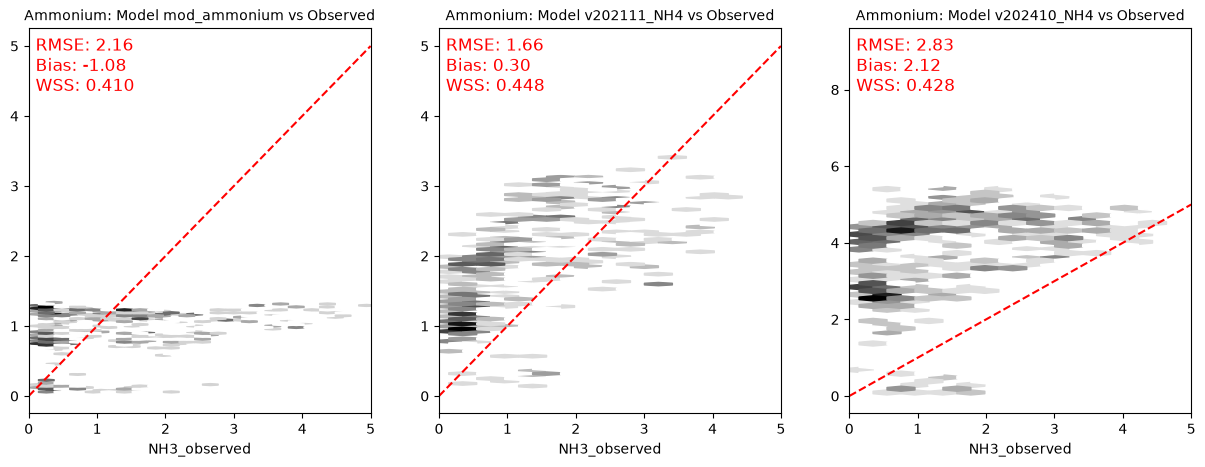

In [12]:
import matplotlib

def plot_o2(ax,data,name = "SHEM"):
    model = np.array(data[name])
    obs = np.array(data['Ammonia'])*71.39
    mask_N = (obs > 0) & (~np.isnan(model))
    rmse, bias, WI,N = calculate_rmse_bias(obs[mask_N], model[mask_N])
    #ax.scatter(obs[mask_N], model[mask_N],color='grey')
    ax.hexbin(obs[mask_N], model[mask_N],gridsize=80, norm=matplotlib.colors.LogNorm(),cmap='Greys')
    ax.set_xlabel('NH3_observed')
    ax.set_title(f'Ammonium: Model {name} vs Observed')

    ax.plot(np.linspace(0, 5),np.linspace(0, 5),'r--')
    ax.text(0.02, 0.98,f'RMSE: {rmse:.2f}\nBias: {bias:.2f}\nWSS: {WI:.3f}',ha='left',va='top',fontsize=12,transform=ax.transAxes,color='red')
    ax.set_xlim(0,5)

fig,axs = plt.subplots(1,3,figsize=(15,5))
plot_o2(axs[0],data,'mod_ammonium')
plot_o2(axs[1],data2,'v202111_NH4')
plot_o2(axs[2],data2,'v202410_NH4')

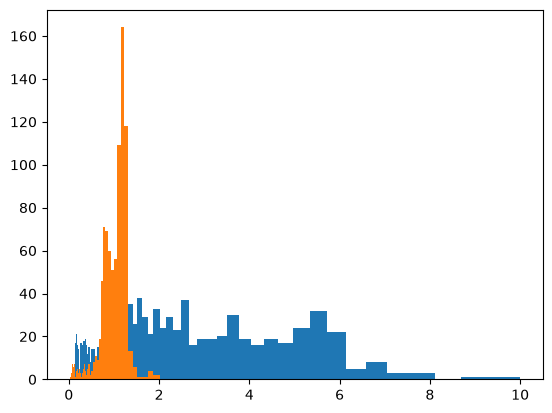

In [14]:
a = plt.hist(data.Ammonia* 71.39,bins = np.logspace(-2,1,100))
a = plt.hist(data.mod_ammonium,bins = np.logspace(-2,1,100))
#a = plt.hist(data.v202111_NH4,bins = np.logspace(-2,1,100))
#a = plt.hist(data.v202410_NH4,bins = np.logspace(-2,1,100))